In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

sys.path.append(os.path.expanduser('~/Code/wmh-mc-seg'))  # For VSCode

In [1]:
from src.datamodules import WMHDataModule
import os
import numpy as np
from notebooks.metrics.utils import (dice_vs_entropy, dice, entropy_boxes,
                                     mcdropout_boxes, uncertainty_confusion,
                                     entropy_volume_ranges, reliability_plots,
                                     probability_volume_ranges, 
                                     error_retention_curve, hausdorff)

In [2]:
data_root = os.path.expanduser('~/Code/datasets/wmh/')
centers_train = ['UtAmSi']
centers_test = ['Utrecht', 'Amsterdam', 'Singapore', 'UMCL']
group_test = {}  # Group for plot

losses = ['CE', 'CE_MEEP', 'CE_KL', 'CE_MEALL']
runs_to_compare = {
    'CE UtAmSi': 'training_Utrecht_Amsterdam_Singapore_CE_3684_best',
    'CE_MEALL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEALL_8766_best',
    'CE_MEEP UtAmSi': 'training_Utrecht_Amsterdam_Singapore_MEEP_6996_best',
    'CE_KL UtAmSi': 'training_Utrecht_Amsterdam_Singapore_cekl_4187_best',
    'Focal UtAmSi': 'training_Utrecht_Amsterdam_Singapore_Focal_5161_best',
}

In [3]:
test_splits = {}
for center in ['Utrecht', 'Amsterdam', 'Singapore']:
    dm = WMHDataModule(data_root, 1, f'training:{center}', [.7, .1, .2],
                       seed=42)
    _, _, ts_spl = dm.generate_splits()
    test_splits[center] = ts_spl

test_splits['UMCL'] = WMHDataModule(
    data_root, 1, 'training:UMCL', [0, 0, 1]).generate_splits()[2]

In [4]:
for key, val in group_test.items():  # Group test datasets if needed
    test_splits[key] = []
    for center in val:
        test_splits[key] += test_splits[center]
        del test_splits[center]
        # Remove center from centers_test
        centers_test.remove(center)
    centers_test.append(key)

In [5]:
plot_data = {
    'centers_train': centers_train,
    'runs_to_compare': runs_to_compare,
    'centers_test': centers_test,
    'test_splits': test_splits,
    'losses': losses,
}

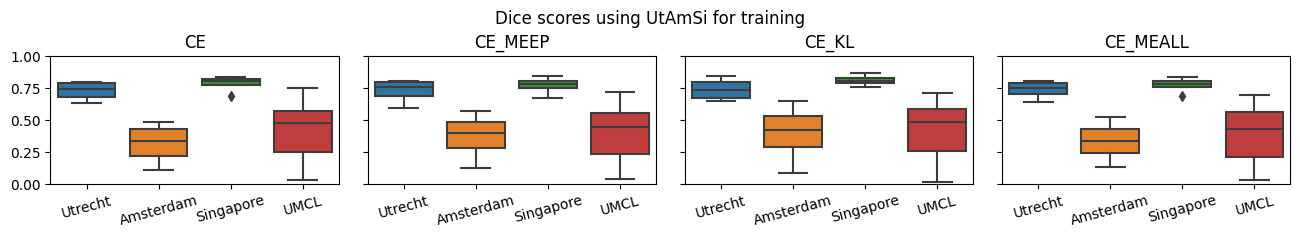

In [7]:
dice(plot_data, use_brain_mask=False)

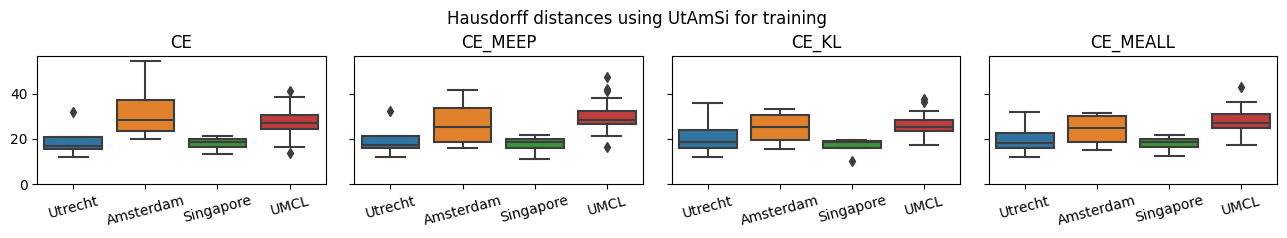

In [6]:
hausdorff(plot_data, use_brain_mask=False)

CE Utrecht - Pearson correlation coefficient: -0.950
CE Amsterdam - Pearson correlation coefficient: -0.920
CE Singapore - Pearson correlation coefficient: 0.152
CE UMCL - Pearson correlation coefficient: -0.937
CE_MEEP Utrecht - Pearson correlation coefficient: -0.974
CE_MEEP Amsterdam - Pearson correlation coefficient: -0.990
CE_MEEP Singapore - Pearson correlation coefficient: -0.046
CE_MEEP UMCL - Pearson correlation coefficient: -0.911
CE_KL Utrecht - Pearson correlation coefficient: -0.908
CE_KL Amsterdam - Pearson correlation coefficient: -0.980
CE_KL Singapore - Pearson correlation coefficient: -0.429
CE_KL UMCL - Pearson correlation coefficient: -0.909
CE_MEALL Utrecht - Pearson correlation coefficient: -0.979
CE_MEALL Amsterdam - Pearson correlation coefficient: -0.883
CE_MEALL Singapore - Pearson correlation coefficient: 0.014
CE_MEALL UMCL - Pearson correlation coefficient: -0.916
CE - Pearson correlation coefficient: -0.855
CE_MEEP - Pearson correlation coefficient: -0.894

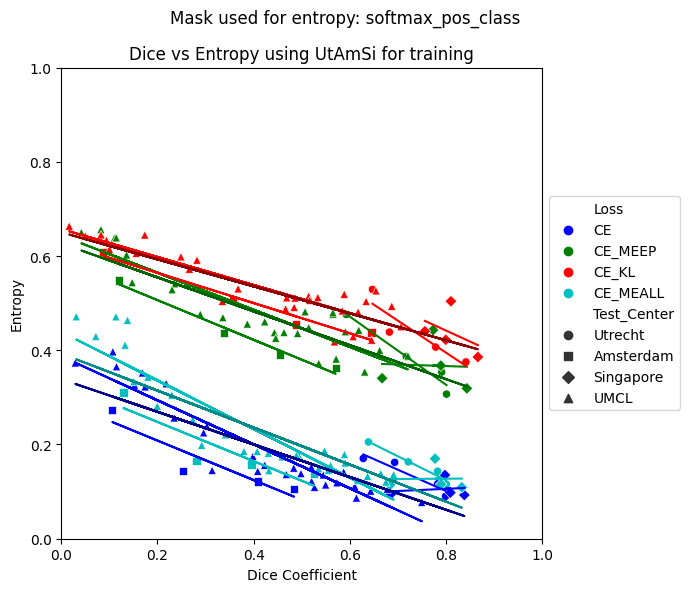

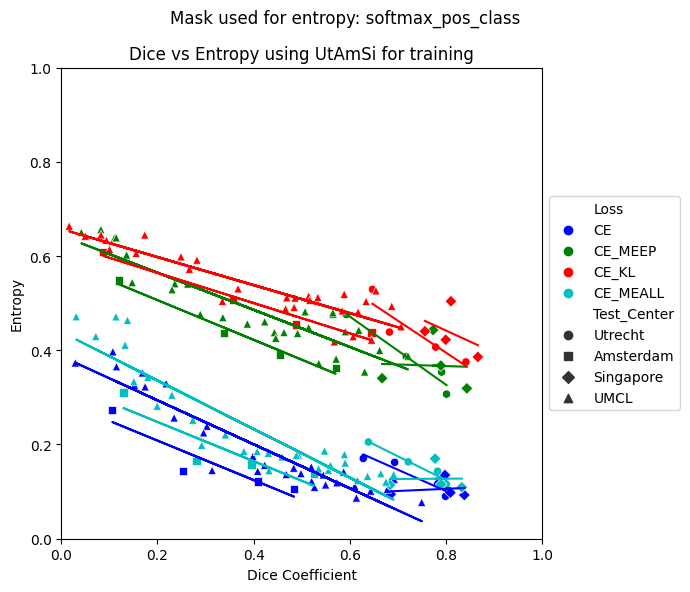

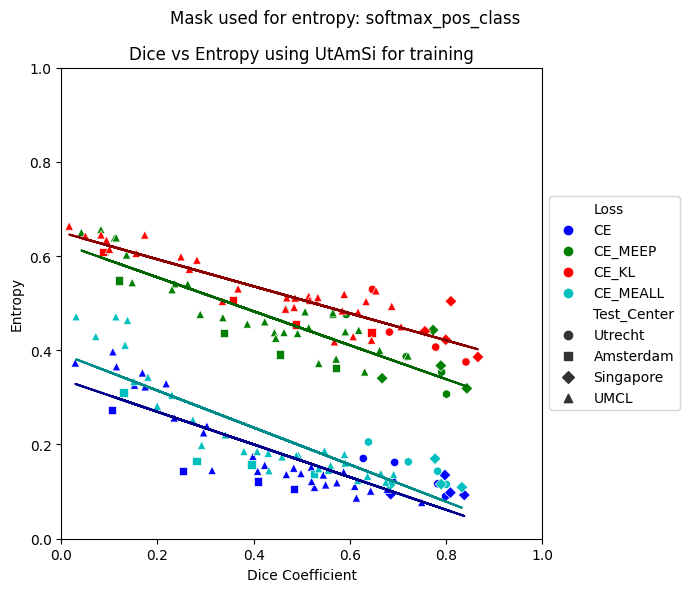

In [8]:
dice_vs_entropy(plot_data, m_type='softmax_pos_class',
                loss_centers_tendencies=True, loss_tendencies=True,
                print_ideal=False, print_metrics=True)
dice_vs_entropy(plot_data, m_type='softmax_pos_class',
                loss_centers_tendencies=True, loss_tendencies=False,
                print_ideal=False, print_metrics=False)
dice_vs_entropy(plot_data, m_type='softmax_pos_class',
                loss_centers_tendencies=False, loss_tendencies=True,
                print_ideal=False, print_metrics=False)

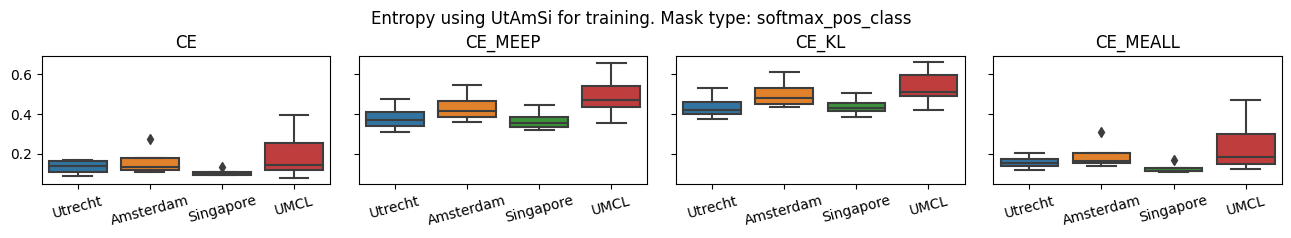

In [9]:
entropy_boxes(plot_data, m_type='softmax_pos_class')

In [10]:
mcdropout_boxes(plot_data)

FileNotFoundError: No such file or no access: '/home/fmatzkin/Code/datasets/wmh/training/Utrecht/27/pred_mc_uncertmc_training_Utrecht_Amsterdam_Singapore_cekl_4187_best.nii.gz'

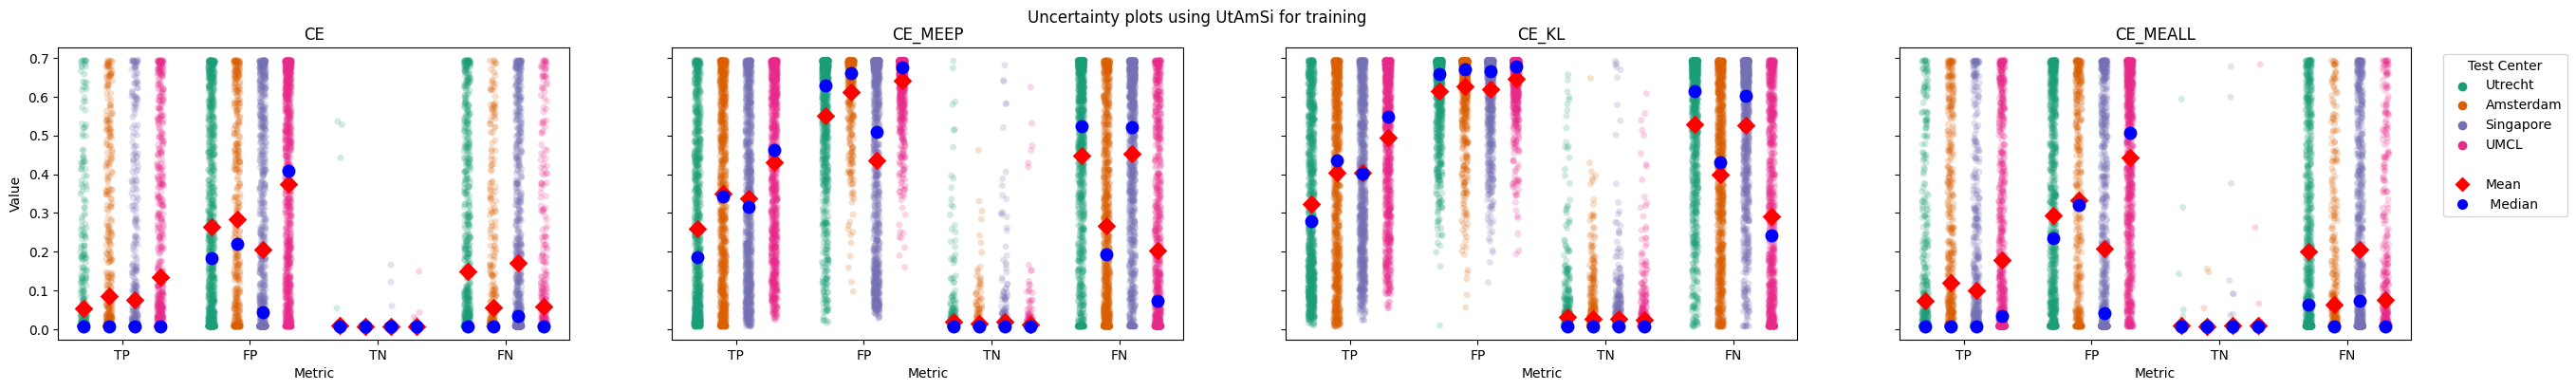

In [17]:
uncertainty_confusion(plot_data, n_samples=1000)

In [18]:
volume_ranges = [(0, 5), (5, 15), (15, np.inf)]

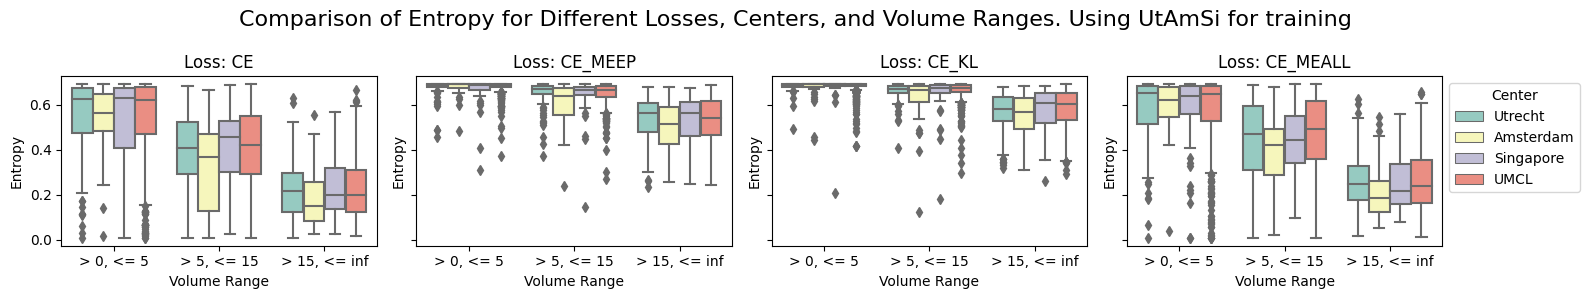

In [19]:
entropy_volume_ranges(plot_data, volume_ranges)

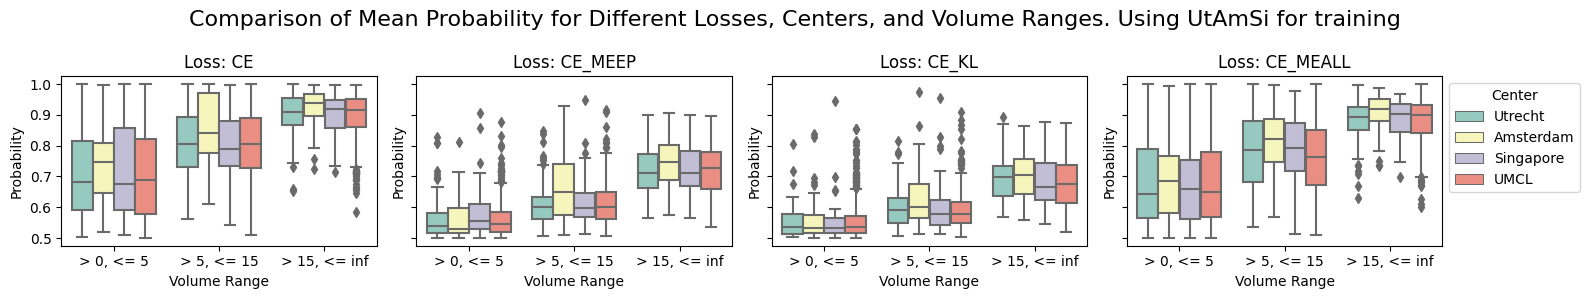

In [20]:
probability_volume_ranges(plot_data, volume_ranges)

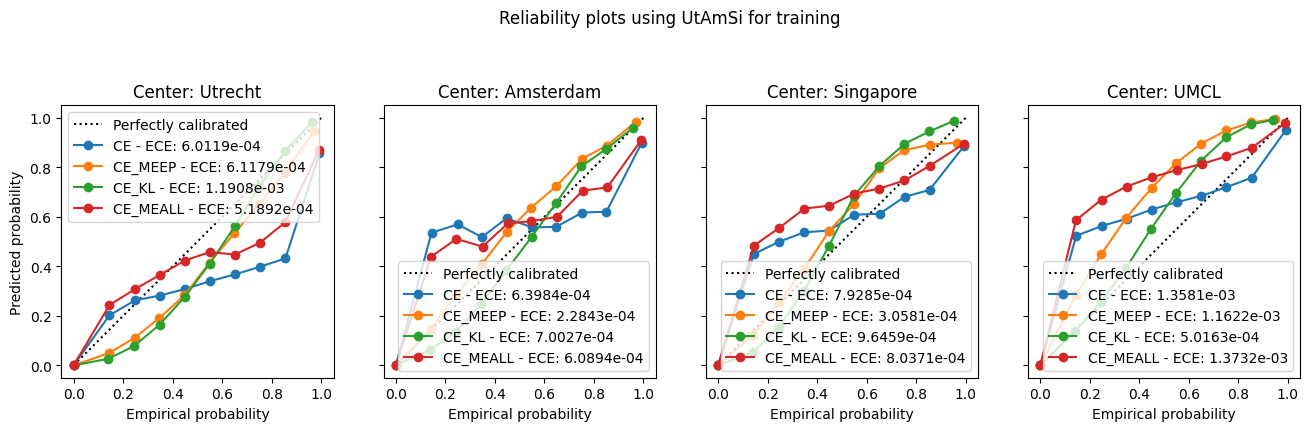

In [21]:
reliability_plots(plot_data)

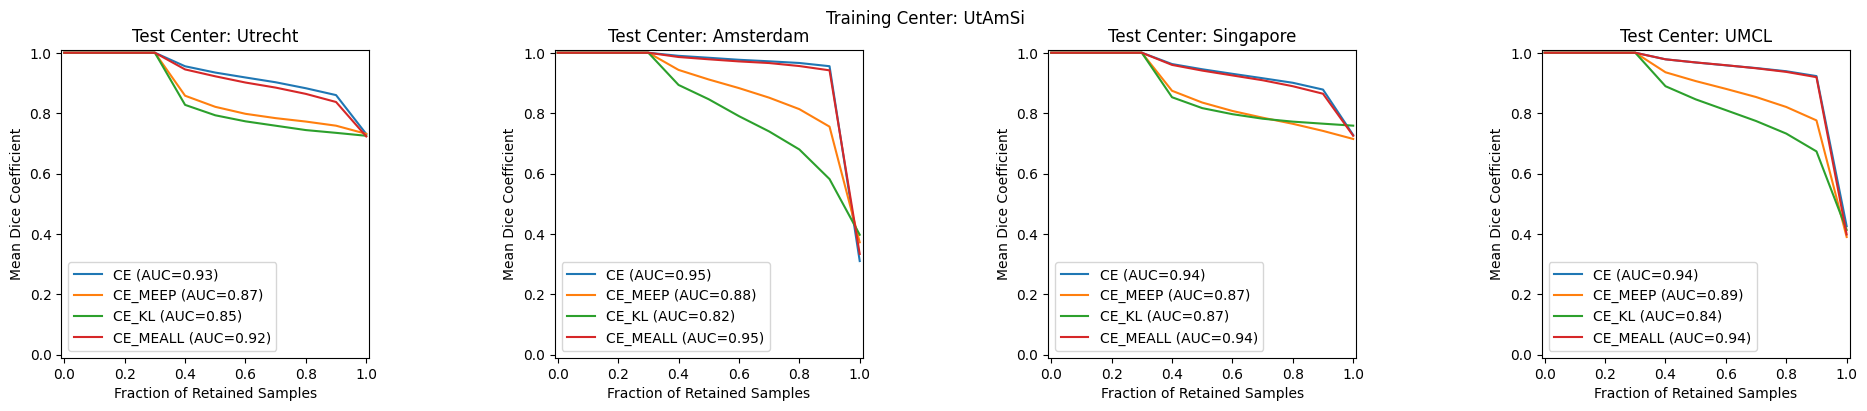

In [6]:
error_retention_curve(plot_data)